# 📘 Notebook 04 — Training & Evaluation: Bi-Encoder CV Matcher

**Project**: CV Matcher Pro — Capstone Dicoding  
**Objective**: Fine-tune `paraphrase-multilingual-MiniLM-L12-v2` pada triplet data (JD↔CV)
untuk menghasilkan model bi-encoder yang mampu mencocokkan CV dengan Job Description.

### Pipeline Overview / Gambaran Alur:
1. ⚙️ Setup & GPU Check
2. 📂 Load Training Data (train/val/test splits)
3. 📊 Baseline Evaluation (sebelum fine-tuning)
4. 🏋️ Fine-tune Bi-Encoder (MNR Loss + Cosine Scheduler)
5. 📈 Post-Training Evaluation (perbandingan baseline vs fine-tuned)
6. 🔍 Qualitative Evaluation (contoh nyata ranking)
7. 🐛 Error Analysis (per-domain breakdown)
8. 💾 Export & Deployment Instructions

> **Catatan**: Notebook ini dirancang untuk Google Colab dengan GPU runtime.
> Pastikan runtime diset ke GPU sebelum menjalankan.

---
## Section 1: ⚙️ Setup & GPU Check
Instalasi dependencies, mount Google Drive, dan verifikasi GPU.

In [1]:
# === Mount Google Drive ===
# Drive digunakan sebagai persistent storage untuk data dan model
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# === Install Dependencies ===
# sentence-transformers: framework utama untuk bi-encoder
# datasets: HuggingFace datasets untuk format training
# scikit-learn: metrics evaluasi
# matplotlib & seaborn: visualisasi training curves
# accelerate: diperlukan oleh HuggingFace Trainer
import subprocess
import sys

packages = [
    'sentence-transformers>=3.0.0',
    'datasets>=2.14.0',
    'scikit-learn>=1.3.0',
    'matplotlib>=3.7.0',
    'seaborn>=0.12.0',
    'accelerate>=0.21.0',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print("✅ Semua dependencies berhasil diinstall / All dependencies installed.")

✅ Semua dependencies berhasil diinstall / All dependencies installed.


In [2]:
# === GPU Check / Verifikasi GPU ===
import torch
import os
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("🔧 SYSTEM INFO / INFORMASI SISTEM")
print("=" * 60)
print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU device       : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    DEVICE = 'cuda'
else:
    print("⚠️  WARNING: GPU tidak tersedia! Training akan sangat lambat.")
    print("   Pastikan Runtime > Change runtime type > GPU")
    DEVICE = 'cpu'

print(f"Active device    : {DEVICE}")
print("=" * 60)

🔧 SYSTEM INFO / INFORMASI SISTEM
PyTorch version  : 2.11.0+cu128
CUDA available   : True
GPU device       : Tesla T4
GPU memory       : 15.6 GB
Active device    : cuda


In [3]:
# === Set Paths / Konfigurasi Path ===
# Semua path mengacu ke folder CVPRO di Google Drive

BASE_DIR = '/content/drive/MyDrive/CVPRO'
DATA_DIR = os.path.join(BASE_DIR, 'data', 'triplets')
MODEL_DIR = os.path.join(BASE_DIR, 'models', 'bi-encoder-cv-matcher')
PLOTS_DIR = os.path.join(BASE_DIR, 'reports')

# Base model — multilingual SBERT, support 50+ bahasa termasuk Indonesia
BASE_MODEL = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'

# Buat directory jika belum ada
for d in [MODEL_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"📂 Data directory  : {DATA_DIR}")
print(f"📂 Model output    : {MODEL_DIR}")
print(f"📂 Plots/reports   : {PLOTS_DIR}")
print(f"🤖 Base model      : {BASE_MODEL}")

# Verify data directory exists
assert os.path.exists(DATA_DIR), (
    f"❌ Data directory tidak ditemukan: {DATA_DIR}\n"
    f"   Jalankan Notebook 03 terlebih dahulu untuk generate triplet data."
)
print("\n✅ Setup selesai / Setup complete!")

📂 Data directory  : /content/drive/MyDrive/CVPRO/data/triplets
📂 Model output    : /content/drive/MyDrive/CVPRO/models/bi-encoder-cv-matcher
📂 Plots/reports   : /content/drive/MyDrive/CVPRO/reports
🤖 Base model      : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2

✅ Setup selesai / Setup complete!


---
## Section 2: 📂 Load Training Data
Memuat dataset triplet yang sudah di-split (train/val/test) dari Notebook 03.
Format: `anchor` (JD), `positive` (CV cocok), `negative` (CV tidak cocok)

In [4]:
import pandas as pd
import numpy as np

# === Load all splits ===
train_path = os.path.join(DATA_DIR, 'train.csv')
val_path   = os.path.join(DATA_DIR, 'val.csv')
test_path  = os.path.join(DATA_DIR, 'test.csv')

# Verifikasi semua file ada
for name, path in [('train', train_path), ('val', val_path), ('test', test_path)]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"❌ File {name}.csv tidak ditemukan di {path}\n"
            f"   Pastikan Notebook 03 sudah dijalankan dan menghasilkan splits."
        )

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

print("=" * 60)
print("📊 DATASET STATISTICS / STATISTIK DATASET")
print("=" * 60)
print(f"{'Split':<10} {'Rows':>8} {'Columns':>10}")
print("-" * 30)
print(f"{'Train':<10} {len(train_df):>8,} {len(train_df.columns):>10}")
print(f"{'Val':<10} {len(val_df):>8,} {len(val_df.columns):>10}")
print(f"{'Test':<10} {len(test_df):>8,} {len(test_df.columns):>10}")
print(f"{'TOTAL':<10} {len(train_df)+len(val_df)+len(test_df):>8,}")
print("-" * 30)

📊 DATASET STATISTICS / STATISTIK DATASET
Split          Rows    Columns
------------------------------
Train         9,984          4
Val           1,248          4
Test          1,248          4
TOTAL        12,480
------------------------------


In [5]:
# === Column Types & Null Check / Tipe Kolom & Pengecekan Null ===
print("\n📋 Column info (train_df):")
print(train_df.dtypes)
print(f"\n🔍 Null values per column:")
print(train_df.isnull().sum())

# Pastikan tidak ada null values — akan mengganggu training
for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    null_count = df[['anchor', 'positive', 'negative']].isnull().sum().sum()
    if null_count > 0:
        print(f"⚠️  WARNING: {split_name} memiliki {null_count} null values. Dropping...")
        df.dropna(subset=['anchor', 'positive', 'negative'], inplace=True)
    else:
        print(f"✅ {split_name}: Tidak ada null values")


📋 Column info (train_df):
anchor      object
positive    object
negative    object
domain      object
dtype: object

🔍 Null values per column:
anchor      0
positive    0
negative    0
domain      0
dtype: int64
✅ train: Tidak ada null values
✅ val: Tidak ada null values
✅ test: Tidak ada null values


In [6]:
# === Text Length Statistics / Statistik Panjang Teks ===
# Penting untuk memahami distribusi panjang teks — mempengaruhi tokenization
print("\n📏 TEXT LENGTH STATISTICS (character count):")
print("-" * 50)

for split_name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    for col in ['anchor', 'positive', 'negative']:
        lengths = df[col].str.len()
        print(f"  {split_name:5s} | {col:10s} → "
              f"mean={lengths.mean():.0f}, "
              f"median={lengths.median():.0f}, "
              f"min={lengths.min():.0f}, "
              f"max={lengths.max():.0f}")
    print()


📏 TEXT LENGTH STATISTICS (character count):
--------------------------------------------------
  Train | anchor     → mean=1767, median=1908, min=156, max=2403
  Train | positive   → mean=883, median=564, min=80, max=2410
  Train | negative   → mean=823, median=500, min=100, max=2000

  Val   | anchor     → mean=1770, median=1910, min=209, max=2361
  Val   | positive   → mean=861, median=562, min=93, max=2296
  Val   | negative   → mean=811, median=492, min=100, max=2000

  Test  | anchor     → mean=1774, median=1912, min=217, max=2313
  Test  | positive   → mean=896, median=594, min=100, max=2253
  Test  | negative   → mean=817, median=488, min=100, max=2000



In [7]:
# === Sample Preview / Contoh Data ===
# Melihat beberapa contoh triplet untuk verifikasi kualitas data
print("🔎 SAMPLE TRIPLETS FROM TRAINING DATA:")
print("=" * 80)

for i in range(min(3, len(train_df))):
    print(f"\n--- Triplet #{i+1} ---")
    print(f"📌 ANCHOR (Job Description):")
    print(f"   {train_df.iloc[i]['anchor'][:200]}...")
    print(f"\n✅ POSITIVE (Matching CV):")
    print(f"   {train_df.iloc[i]['positive'][:200]}...")
    print(f"\n❌ NEGATIVE (Non-matching CV):")
    print(f"   {train_df.iloc[i]['negative'][:200]}...")
    print("-" * 80)

🔎 SAMPLE TRIPLETS FROM TRAINING DATA:

--- Triplet #1 ---
📌 ANCHOR (Job Description):
   The Department of Pediatrics, Section of Pediatrics Hospitalist Medicine at Tulane University School of Medicine in New Orleans, in partnership with the Children’s Hospital of New Orleans (CHNOLA), is...

✅ POSITIVE (Matching CV):
   experiences, designed, maintained and updated eLearning and ILT training materials, created and maintained training project time lines, ensured quality content and materials, included instructional pe...

❌ NEGATIVE (Non-matching CV):
   Skills Corporate Accounting, Accounting Operations, Audits, Cash, Filing, Financial Statements, General Ledger Reconciliations, Payroll and PR Reconciliations, Accounts Payable, Bank Reconciliations, ...
--------------------------------------------------------------------------------

--- Triplet #2 ---
📌 ANCHOR (Job Description):
   Pemegang jabatan dalam posisi ini bertanggung jawab untuk memberikan layanan yang unggul baik kepada pe

---
## Section 3: 📊 Baseline Evaluation (Sebelum Fine-tuning)
Evaluasi model dasar TANPA fine-tuning untuk mendapatkan baseline metrics.
Ini penting sebagai pembanding — seberapa banyak improvement dari fine-tuning.

**Metric**: Triplet Accuracy — persentase di mana model memberikan
similarity score lebih tinggi ke positive pair dibanding negative pair.

In [8]:
from sentence_transformers import SentenceTransformer, util, evaluation
import time

print("🤖 Loading base model (tanpa fine-tuning)...")
print(f"   Model: {BASE_MODEL}")
start_time = time.time()

base_model = SentenceTransformer(BASE_MODEL, device=DEVICE)

load_time = time.time() - start_time
print(f"✅ Model loaded in {load_time:.1f}s")
print(f"   Model parameters: {sum(p.numel() for p in base_model.parameters()):,}")
print(f"   Max seq length: {base_model.max_seq_length}")

🤖 Loading base model (tanpa fine-tuning)...
   Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded in 14.7s
   Model parameters: 117,653,760
   Max seq length: 128


In [10]:
# === Baseline Triplet Accuracy on Test Set ===
# TripletEvaluator menghitung: untuk setiap triplet, apakah
# cos_sim(anchor, positive) > cos_sim(anchor, negative)?

print("\n📊 Evaluating baseline model on TEST set...")
print("   (Ini mungkin memakan waktu beberapa menit / This may take a few minutes)")

baseline_evaluator = evaluation.TripletEvaluator(
    anchors=test_df['anchor'].tolist(),
    positives=test_df['positive'].tolist(),
    negatives=test_df['negative'].tolist(),
    name='baseline_test',
    batch_size=64,
)

baseline_test_score = baseline_evaluator(base_model)

# Fix: TripletEvaluator returns dict in newer versions
if isinstance(baseline_test_score, dict):
    print(f"   Raw result: {baseline_test_score}")
    baseline_test_score = list(baseline_test_score.values())[0]

print(f"   Cosine Accuracy: {baseline_test_score:.4f} ({baseline_test_score*100:.2f}%)")
print(f"\n{'=' * 50}")
print(f"🎯 BASELINE TRIPLET ACCURACY (Test Set)")
print(f"{'=' * 50}")
print(f"   Cosine Accuracy: {baseline_test_score:.4f} ({baseline_test_score*100:.2f}%)")
print(f"{'=' * 50}")


📊 Evaluating baseline model on TEST set...
   (Ini mungkin memakan waktu beberapa menit / This may take a few minutes)
   Raw result: {'baseline_test_cosine_accuracy': 0.6546474099159241}
   Cosine Accuracy: 0.6546 (65.46%)

🎯 BASELINE TRIPLET ACCURACY (Test Set)
   Cosine Accuracy: 0.6546 (65.46%)


In [12]:
# === Baseline on Validation Set (untuk perbandingan nanti) ===
print("\n📊 Evaluating baseline model on VALIDATION set...")

baseline_val_evaluator = evaluation.TripletEvaluator(
    anchors=val_df['anchor'].tolist(),
    positives=val_df['positive'].tolist(),
    negatives=val_df['negative'].tolist(),
    name='baseline_val',
    batch_size=64,
)

baseline_val_score = baseline_val_evaluator(base_model)

if isinstance(baseline_val_score, dict):
    baseline_val_score = list(baseline_val_score.values())[0]

print(f"   Baseline Val Accuracy: {baseline_val_score:.4f} ({baseline_val_score*100:.2f}%)")
print(f"   Baseline Val Accuracy: {baseline_val_score:.4f} ({baseline_val_score*100:.2f}%)")


📊 Evaluating baseline model on VALIDATION set...
   Baseline Val Accuracy: 0.6386 (63.86%)
   Baseline Val Accuracy: 0.6386 (63.86%)



📊 Computing similarity distributions (baseline)...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

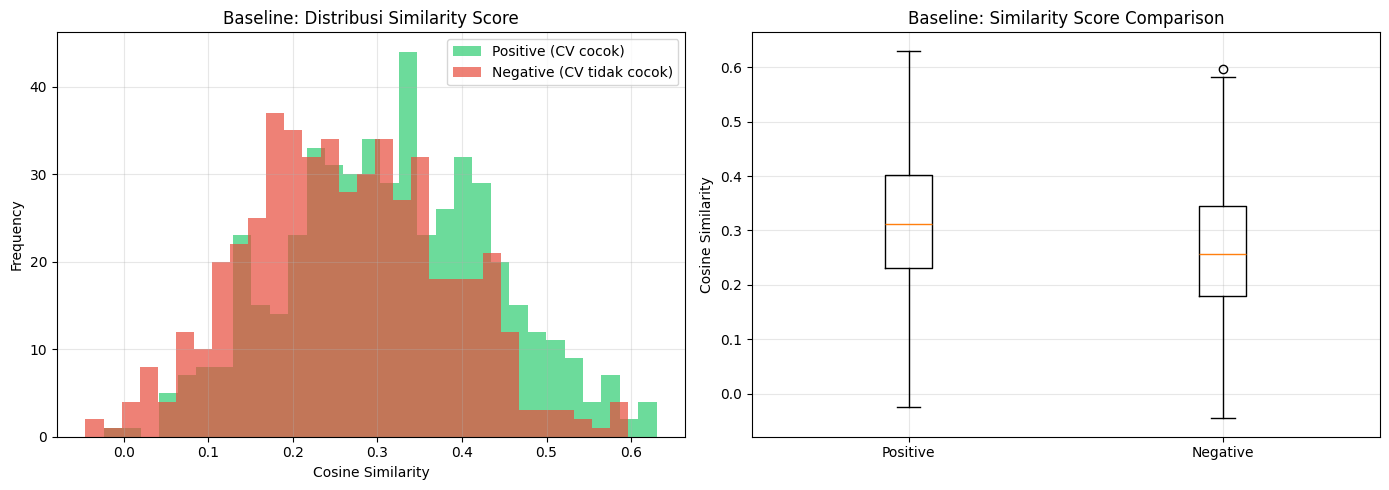

📊 Plot saved to: /content/drive/MyDrive/CVPRO/reports/baseline_similarity_distribution.png

   Positive similarities → mean=0.3157, std=0.1224
   Negative similarities → mean=0.2629, std=0.1185
   Separation gap        → 0.0529

🧹 Base model removed from memory (freed GPU for training)


In [13]:
# === Baseline Similarity Score Distribution ===
# Visualisasi distribusi cosine similarity untuk positive vs negative pairs
import matplotlib.pyplot as plt
import seaborn as sns

print("\n📊 Computing similarity distributions (baseline)...")

# Encode subsets for visualization (limit to 500 for speed)
n_viz = min(500, len(test_df))
viz_df = test_df.head(n_viz)

anchor_embs = base_model.encode(viz_df['anchor'].tolist(), batch_size=64, show_progress_bar=True)
pos_embs    = base_model.encode(viz_df['positive'].tolist(), batch_size=64, show_progress_bar=True)
neg_embs    = base_model.encode(viz_df['negative'].tolist(), batch_size=64, show_progress_bar=True)

# Compute cosine similarities
pos_sims = [util.cos_sim(anchor_embs[i], pos_embs[i]).item() for i in range(n_viz)]
neg_sims = [util.cos_sim(anchor_embs[i], neg_embs[i]).item() for i in range(n_viz)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution plot
axes[0].hist(pos_sims, bins=30, alpha=0.7, label='Positive (CV cocok)', color='#2ecc71')
axes[0].hist(neg_sims, bins=30, alpha=0.7, label='Negative (CV tidak cocok)', color='#e74c3c')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Baseline: Distribusi Similarity Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot([pos_sims, neg_sims], labels=['Positive', 'Negative'])
axes[1].set_ylabel('Cosine Similarity')
axes[1].set_title('Baseline: Similarity Score Comparison')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
baseline_dist_path = os.path.join(PLOTS_DIR, 'baseline_similarity_distribution.png')
plt.savefig(baseline_dist_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Plot saved to: {baseline_dist_path}")

# Print statistics
print(f"\n   Positive similarities → mean={np.mean(pos_sims):.4f}, std={np.std(pos_sims):.4f}")
print(f"   Negative similarities → mean={np.mean(neg_sims):.4f}, std={np.std(neg_sims):.4f}")
print(f"   Separation gap        → {np.mean(pos_sims) - np.mean(neg_sims):.4f}")

# Cleanup base model from GPU memory before training
del base_model, anchor_embs, pos_embs, neg_embs
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\n🧹 Base model removed from memory (freed GPU for training)")

---
## Section 4: 🏋️ Fine-tune Bi-Encoder
Fine-tuning menggunakan:
- **MultipleNegativesRankingLoss (MNR)**: Loss function yang efektif untuk retrieval tasks.
  Setiap positive pair dalam batch menjadi negative untuk pair lainnya → sangat efisien.
- **Cosine LR Scheduler** dengan warmup: Stabilitas training lebih baik.
- **Early Stopping**: Menghentikan training jika tidak ada improvement selama 2 epoch.
- **FP16**: Mixed precision untuk training lebih cepat di GPU.

### Hyperparameter Choices / Pemilihan Hyperparameter:
| Parameter | Value | Alasan |
|-----------|-------|--------|
| Batch Size | 32 | Sweet spot antara speed & GPU memory |
| Learning Rate | 2e-5 | Standard untuk fine-tuning BERT-based models |
| Epochs | 5 | Cukup dengan early stopping |
| Warmup Ratio | 0.1 | 10% steps pertama untuk stabilitas |
| Scheduler | Cosine | Gradual decay lebih halus dari linear |

In [14]:
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainingArguments,
    SentenceTransformerTrainer,
    losses,
    evaluation,
)
from datasets import Dataset
from transformers import EarlyStoppingCallback

# === Initialize fresh model for fine-tuning ===
print("🤖 Loading fresh base model for fine-tuning...")
model = SentenceTransformer(BASE_MODEL, device=DEVICE)
print(f"✅ Model loaded: {BASE_MODEL}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

🤖 Loading fresh base model for fine-tuning...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Model loaded: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
   Parameters: 117,653,760


In [15]:
# === Prepare Datasets in HuggingFace format ===
# sentence-transformers v3+ menggunakan HuggingFace Datasets format
# Kolom harus: anchor, positive, negative (untuk triplet training)

print("📦 Preparing datasets...")

# Pastikan hanya kolom yang diperlukan
train_dataset = Dataset.from_pandas(
    train_df[['anchor', 'positive', 'negative']].reset_index(drop=True)
).shuffle(seed=42)

eval_dataset = Dataset.from_pandas(
    val_df[['anchor', 'positive', 'negative']].reset_index(drop=True)
)

print(f"   Train dataset : {len(train_dataset):,} samples")
print(f"   Eval dataset  : {len(eval_dataset):,} samples")
print(f"   Columns       : {train_dataset.column_names}")

📦 Preparing datasets...
   Train dataset : 9,984 samples
   Eval dataset  : 1,248 samples
   Columns       : ['anchor', 'positive', 'negative']


In [16]:
# === Configure Loss Function ===
# MNR Loss: In-batch negatives + explicit hard negatives dari kolom 'negative'
# Sangat efektif karena batch_size=32 berarti setiap anchor punya 31 implicit negatives
# ditambah 1 explicit hard negative → total 32 negatives per anchor

train_loss = losses.MultipleNegativesRankingLoss(model)
print(f"📉 Loss function: MultipleNegativesRankingLoss")
print(f"   Scale: {train_loss.scale}")

📉 Loss function: MultipleNegativesRankingLoss
   Scale: 20.0


In [17]:
# === Configure Evaluator ===
# TripletEvaluator dijalankan setiap akhir epoch untuk monitor progress
# Menggunakan validation set (bukan test set — test hanya untuk evaluasi akhir)

evaluator = evaluation.TripletEvaluator(
    anchors=val_df['anchor'].tolist(),
    positives=val_df['positive'].tolist(),
    negatives=val_df['negative'].tolist(),
    name='val_triplet',
    batch_size=64,
)
print("📊 Evaluator: TripletEvaluator on validation set")

📊 Evaluator: TripletEvaluator on validation set


In [19]:
# === Training Arguments ===
OUTPUT_DIR = MODEL_DIR

training_args = SentenceTransformerTrainingArguments(
    output_dir=OUTPUT_DIR,

    # --- Training schedule ---
    num_train_epochs=5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    # --- Optimizer ---
    learning_rate=2e-5,
    warmup_steps=0.1,              # In v5+, float = ratio, int = exact steps
    lr_scheduler_type='cosine',    # Cosine annealing — smooth decay
    weight_decay=0.01,             # L2 regularization ringan

    # --- Evaluation & Saving ---
    eval_strategy='epoch',         # Evaluasi setiap akhir epoch
    save_strategy='epoch',         # Save checkpoint setiap epoch
    load_best_model_at_end=True,   # Load model terbaik saat training selesai
    metric_for_best_model='eval_loss',
    greater_is_better=False,       # eval_loss: semakin kecil semakin baik
    save_total_limit=2,            # Simpan max 2 checkpoints (hemat storage)

    # --- Logging ---
    logging_steps=50,              # Log setiap 50 steps
    logging_first_step=True,       # Log step pertama
    report_to='none',              # Disable wandb/tensorboard (gunakan manual plots)

    # --- Performance ---
    fp16=torch.cuda.is_available(),  # Mixed precision jika GPU tersedia
    dataloader_num_workers=2,        # Parallel data loading
    dataloader_pin_memory=True,      # Faster GPU transfer

    # --- Reproducibility ---
    seed=42,
)

print("\n🔧 TRAINING CONFIGURATION:")
print(f"   Epochs           : {training_args.num_train_epochs}")
print(f"   Batch size        : {training_args.per_device_train_batch_size}")
print(f"   Learning rate     : {training_args.learning_rate}")
print(f"   Warmup ratio      : {training_args.warmup_ratio}")
print(f"   LR scheduler      : {training_args.lr_scheduler_type}")
print(f"   FP16              : {training_args.fp16}")
print(f"   Early stopping    : patience=2 epochs")
print(f"   Output directory  : {OUTPUT_DIR}")

# Estimate steps
steps_per_epoch = len(train_dataset) // training_args.per_device_train_batch_size
total_steps = steps_per_epoch * int(training_args.num_train_epochs)
warmup_steps = int(total_steps * 0.1)
print(f"\n   Estimated steps/epoch : {steps_per_epoch}")
print(f"   Estimated total steps : {total_steps}")
print(f"   Estimated warmup steps: {warmup_steps}")


🔧 TRAINING CONFIGURATION:
   Epochs           : 5
   Batch size        : 32
   Learning rate     : 2e-05
   Warmup ratio      : None
   LR scheduler      : SchedulerType.COSINE
   FP16              : True
   Early stopping    : patience=2 epochs
   Output directory  : /content/drive/MyDrive/CVPRO/models/bi-encoder-cv-matcher

   Estimated steps/epoch : 312
   Estimated total steps : 1560
   Estimated warmup steps: 156


In [20]:
# === Initialize Trainer & Start Training ===
print("\n" + "=" * 60)
print("🚀 STARTING BI-ENCODER FINE-TUNING")
print("=" * 60)

trainer = SentenceTransformerTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    loss=train_loss,
    evaluator=evaluator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# Track training time
training_start = time.time()

# === TRAIN! ===
trainer.train()

training_time = time.time() - training_start
training_minutes = training_time / 60

print(f"\n{'=' * 60}")
print(f"✅ TRAINING COMPLETE / TRAINING SELESAI!")
print(f"{'=' * 60}")
print(f"   Duration: {training_minutes:.1f} minutes ({training_time:.0f} seconds)")


🚀 STARTING BI-ENCODER FINE-TUNING


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.


Epoch,Training Loss,Validation Loss,Val Triplet Cosine Accuracy
1,3.248316,3.183942,0.820513
2,3.070318,3.083613,0.834936
3,2.850058,3.067482,0.841346
4,2.632393,3.118979,0.834135
5,2.561745,3.163363,0.833333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


✅ TRAINING COMPLETE / TRAINING SELESAI!
   Duration: 9.8 minutes (589 seconds)


In [21]:
# === Save Final Model ===
# save_pretrained menyimpan model weights + tokenizer + config
print(f"\n💾 Saving fine-tuned model to: {OUTPUT_DIR}")
model.save_pretrained(OUTPUT_DIR)
print(f"✅ Model saved successfully!")

# List saved files
saved_files = os.listdir(OUTPUT_DIR)
print(f"\n📁 Files in model directory ({len(saved_files)} files):")
for f in sorted(saved_files)[:15]:
    fpath = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f"   📄 {f} ({size_mb:.1f} MB)")
    else:
        print(f"   📂 {f}/")


💾 Saving fine-tuned model to: /content/drive/MyDrive/CVPRO/models/bi-encoder-cv-matcher


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved successfully!

📁 Files in model directory (12 files):
   📂 1_Pooling/
   📄 README.md (0.1 MB)
   📂 checkpoint-1560/
   📂 checkpoint-936/
   📄 config.json (0.0 MB)
   📄 config_sentence_transformers.json (0.0 MB)
   📂 eval/
   📄 model.safetensors (448.8 MB)
   📄 modules.json (0.0 MB)
   📄 sentence_bert_config.json (0.0 MB)
   📄 tokenizer.json (16.3 MB)
   📄 tokenizer_config.json (0.0 MB)


---
## Section 5: 📈 Post-Training Evaluation
Evaluasi model setelah fine-tuning dan perbandingan dengan baseline.
Ini adalah validasi utama apakah fine-tuning berhasil meningkatkan performa.

In [22]:
# === Load Fine-tuned Model (fresh load untuk evaluasi bersih) ===
print("🤖 Loading fine-tuned model for evaluation...")
finetuned_model = SentenceTransformer(OUTPUT_DIR, device=DEVICE)
print(f"✅ Fine-tuned model loaded from: {OUTPUT_DIR}")

🤖 Loading fine-tuned model for evaluation...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Fine-tuned model loaded from: /content/drive/MyDrive/CVPRO/models/bi-encoder-cv-matcher


In [23]:
# === Evaluate on Test Set ===
print("\n📊 Evaluating fine-tuned model on TEST set...")

finetuned_test_evaluator = evaluation.TripletEvaluator(
    anchors=test_df['anchor'].tolist(),
    positives=test_df['positive'].tolist(),
    negatives=test_df['negative'].tolist(),
    name='finetuned_test',
    batch_size=64,
)

finetuned_test_score = finetuned_test_evaluator(finetuned_model)

# === Also evaluate on validation set ===
print("📊 Evaluating fine-tuned model on VALIDATION set...")

finetuned_val_evaluator = evaluation.TripletEvaluator(
    anchors=val_df['anchor'].tolist(),
    positives=val_df['positive'].tolist(),
    negatives=val_df['negative'].tolist(),
    name='finetuned_val',
    batch_size=64,
)

finetuned_val_score = finetuned_val_evaluator(finetuned_model)


📊 Evaluating fine-tuned model on TEST set...
📊 Evaluating fine-tuned model on VALIDATION set...


In [26]:
# === Results Comparison Table / Tabel Perbandingan ===
print("\n" + "=" * 65)
print("📊 EVALUATION RESULTS: BASELINE vs FINE-TUNED")
print("=" * 65)

if isinstance(finetuned_test_score, dict):
    finetuned_test_score = list(finetuned_test_score.values())[0]
if isinstance(finetuned_val_score, dict):
    finetuned_val_score = list(finetuned_val_score.values())[0]

# Create comparison table
comparison_data = {
    'Metric': [
        'Triplet Accuracy (Test)',
        'Triplet Accuracy (Val)',
    ],
    'Baseline': [
        f"{baseline_test_score:.4f} ({baseline_test_score*100:.2f}%)",
        f"{baseline_val_score:.4f} ({baseline_val_score*100:.2f}%)",
    ],
    'Fine-tuned': [
        f"{finetuned_test_score:.4f} ({finetuned_test_score*100:.2f}%)",
        f"{finetuned_val_score:.4f} ({finetuned_val_score*100:.2f}%)",
    ],
    'Improvement': [
        f"+{(finetuned_test_score - baseline_test_score)*100:.2f}%",
        f"+{(finetuned_val_score - baseline_val_score)*100:.2f}%",
    ],
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print("=" * 65)

# Verdict
test_improvement = (finetuned_test_score - baseline_test_score) * 100
if test_improvement > 0:
    print(f"\n🎉 Fine-tuning berhasil! Test accuracy meningkat {test_improvement:.2f}%")
elif test_improvement == 0:
    print(f"\n⚠️  Tidak ada perubahan. Pertimbangkan data augmentation atau hyperparameter tuning.")
else:
    print(f"\n❌ Fine-tuning menurunkan performa. Cek overfitting atau kualitas data.")


📊 EVALUATION RESULTS: BASELINE vs FINE-TUNED
                 Metric        Baseline      Fine-tuned Improvement
Triplet Accuracy (Test) 0.6546 (65.46%) 0.8341 (83.41%)     +17.95%
 Triplet Accuracy (Val) 0.6386 (63.86%) 0.8413 (84.13%)     +20.27%

🎉 Fine-tuning berhasil! Test accuracy meningkat 17.95%



📈 Plotting training curves...


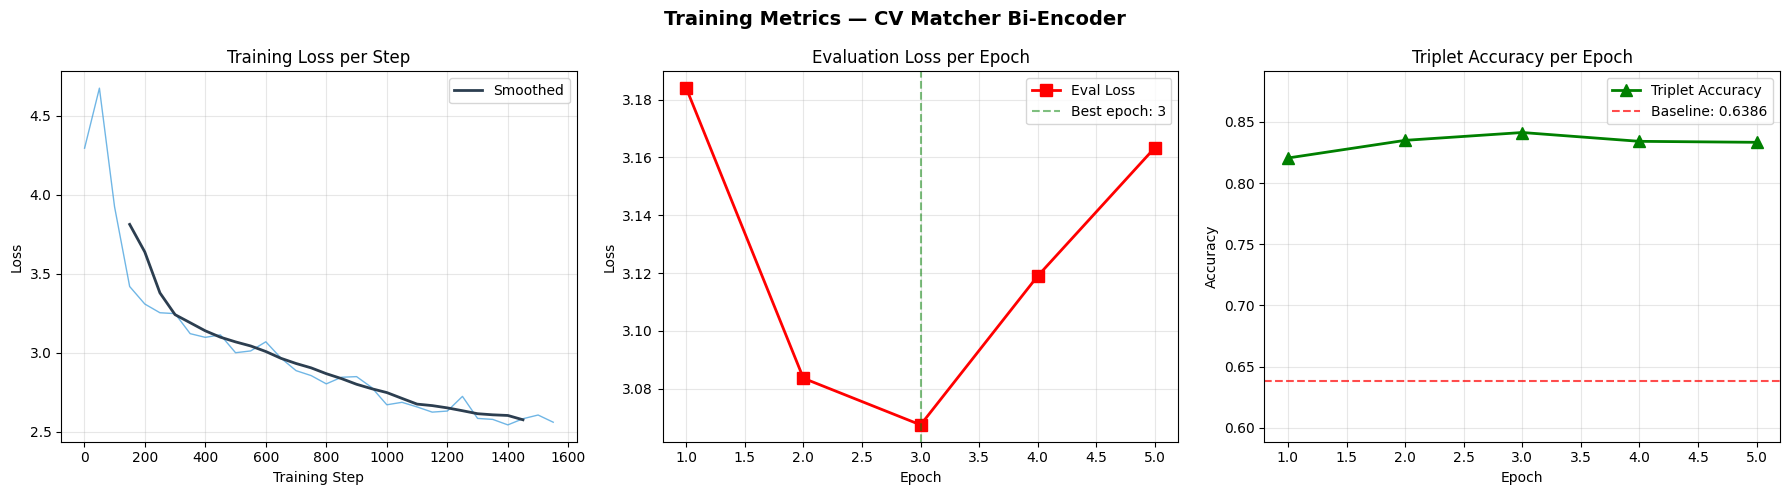

📊 Plot saved to: /content/drive/MyDrive/CVPRO/reports/training_metrics.png
📊 Plot also saved to: /content/drive/MyDrive/CVPRO/models/bi-encoder-cv-matcher/training_metrics.png


<Figure size 640x480 with 0 Axes>

In [27]:
# === Plot Training Curves / Kurva Training ===
# Menggunakan trainer.state.log_history untuk mengekstrak metrics per step/epoch

print("\n📈 Plotting training curves...")

# Extract metrics dari training history
log_history = trainer.state.log_history

train_steps, train_losses = [], []
eval_epochs, eval_losses = [], []
acc_epochs, acc_scores = [], []

for entry in log_history:
    epoch = entry.get('epoch', None)

    # Training loss (logged per N steps)
    if 'loss' in entry and 'eval_loss' not in entry:
        train_steps.append(entry.get('step', 0))
        train_losses.append(entry['loss'])

    # Eval loss (logged per epoch)
    if 'eval_loss' in entry:
        eval_epochs.append(epoch)
        eval_losses.append(entry['eval_loss'])

    # Triplet accuracy (logged by evaluator)
    for k, v in entry.items():
        if 'accuracy_cosine' in k.lower() or 'triplet' in k.lower():
            if isinstance(v, (int, float)):
                acc_epochs.append(epoch)
                acc_scores.append(v)
                break

# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Training Loss per Step ---
if train_losses:
    axes[0].plot(train_steps, train_losses, color='#3498db', alpha=0.7, linewidth=1)
    # Add smoothed line (moving average)
    if len(train_losses) > 10:
        window = min(20, len(train_losses) // 5)
        smoothed = pd.Series(train_losses).rolling(window=window, center=True).mean()
        axes[0].plot(train_steps, smoothed, color='#2c3e50', linewidth=2, label='Smoothed')
        axes[0].legend()
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss per Step')
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Train vs Eval Loss per Epoch ---
if eval_losses:
    axes[1].plot(eval_epochs, eval_losses, 'rs-', label='Eval Loss', linewidth=2, markersize=8)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Evaluation Loss per Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    # Mark best epoch
    best_epoch_idx = np.argmin(eval_losses)
    axes[1].axvline(x=eval_epochs[best_epoch_idx], color='green', linestyle='--',
                     alpha=0.5, label=f'Best epoch: {eval_epochs[best_epoch_idx]:.0f}')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Eval loss data not available',
                 ha='center', va='center', transform=axes[1].transAxes)

# --- Plot 3: Triplet Accuracy per Epoch ---
if acc_scores:
    axes[2].plot(acc_epochs, acc_scores, 'g^-', label='Triplet Accuracy', linewidth=2, markersize=8)
    # Add baseline reference line
    axes[2].axhline(y=baseline_val_score, color='red', linestyle='--',
                     alpha=0.7, label=f'Baseline: {baseline_val_score:.4f}')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Accuracy')
    axes[2].set_title('Triplet Accuracy per Epoch')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(
        max(0, min(min(acc_scores), baseline_val_score) - 0.05),
        min(1, max(max(acc_scores), baseline_val_score) + 0.05)
    )
else:
    axes[2].text(0.5, 0.5, 'Accuracy data not available',
                 ha='center', va='center', transform=axes[2].transAxes)

plt.suptitle('Training Metrics — CV Matcher Bi-Encoder', fontsize=14, fontweight='bold')
plt.tight_layout()

metrics_plot_path = os.path.join(PLOTS_DIR, 'training_metrics.png')
plt.savefig(metrics_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Plot saved to: {metrics_plot_path}")

# Also save to model directory for easy access
metrics_model_path = os.path.join(MODEL_DIR, 'training_metrics.png')
plt.savefig(metrics_model_path, dpi=150, bbox_inches='tight')
print(f"📊 Plot also saved to: {metrics_model_path}")


📊 Computing similarity distributions (fine-tuned model)...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

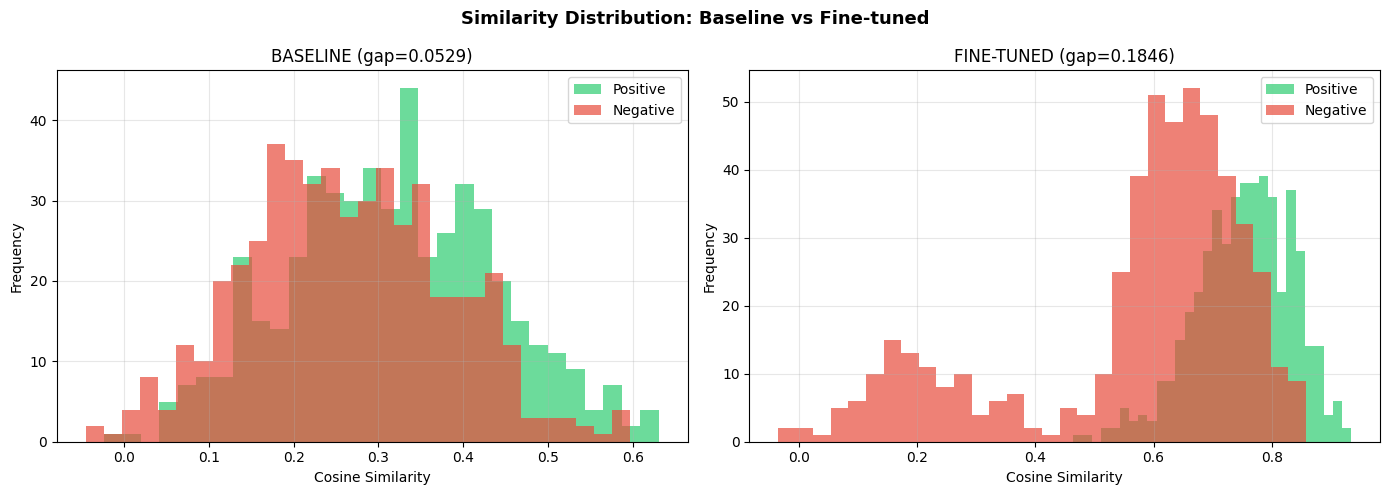

📊 Plot saved to: /content/drive/MyDrive/CVPRO/reports/similarity_distribution_comparison.png

📊 Separation gap improvement:
   Baseline   : 0.0529
   Fine-tuned : 0.1846
   Improvement: 0.1318


In [28]:
# === Post-training Similarity Distribution ===
print("\n📊 Computing similarity distributions (fine-tuned model)...")

n_viz = min(500, len(test_df))
viz_df = test_df.head(n_viz)

ft_anchor_embs = finetuned_model.encode(viz_df['anchor'].tolist(), batch_size=64, show_progress_bar=True)
ft_pos_embs    = finetuned_model.encode(viz_df['positive'].tolist(), batch_size=64, show_progress_bar=True)
ft_neg_embs    = finetuned_model.encode(viz_df['negative'].tolist(), batch_size=64, show_progress_bar=True)

ft_pos_sims = [util.cos_sim(ft_anchor_embs[i], ft_pos_embs[i]).item() for i in range(n_viz)]
ft_neg_sims = [util.cos_sim(ft_anchor_embs[i], ft_neg_embs[i]).item() for i in range(n_viz)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline distribution
axes[0].hist(pos_sims, bins=30, alpha=0.7, label='Positive', color='#2ecc71')
axes[0].hist(neg_sims, bins=30, alpha=0.7, label='Negative', color='#e74c3c')
axes[0].set_title(f'BASELINE (gap={np.mean(pos_sims)-np.mean(neg_sims):.4f})')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fine-tuned distribution
axes[1].hist(ft_pos_sims, bins=30, alpha=0.7, label='Positive', color='#2ecc71')
axes[1].hist(ft_neg_sims, bins=30, alpha=0.7, label='Negative', color='#e74c3c')
axes[1].set_title(f'FINE-TUNED (gap={np.mean(ft_pos_sims)-np.mean(ft_neg_sims):.4f})')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Similarity Distribution: Baseline vs Fine-tuned', fontsize=13, fontweight='bold')
plt.tight_layout()

dist_compare_path = os.path.join(PLOTS_DIR, 'similarity_distribution_comparison.png')
plt.savefig(dist_compare_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Plot saved to: {dist_compare_path}")

print(f"\n📊 Separation gap improvement:")
print(f"   Baseline   : {np.mean(pos_sims)-np.mean(neg_sims):.4f}")
print(f"   Fine-tuned : {np.mean(ft_pos_sims)-np.mean(ft_neg_sims):.4f}")
print(f"   Improvement: {(np.mean(ft_pos_sims)-np.mean(ft_neg_sims))-(np.mean(pos_sims)-np.mean(neg_sims)):.4f}")

---
## Section 6: 🔍 Qualitative Evaluation
Evaluasi kualitatif menggunakan contoh nyata.
Kita ambil beberapa JD lalu ranking CV chunks berdasarkan similarity score.
Ini membantu memahami bagaimana model "berpikir" dalam skenario nyata.

In [29]:
# === Define Example JDs and CVs for Qualitative Testing ===
# Contoh JD dan CV untuk testing kualitatif
# Campuran bahasa Indonesia dan Inggris (bilingual)

sample_jds = [
    # IT / Software Engineering
    "We are looking for a Software Engineer with 3+ years of experience in Python, "
    "Django, and REST APIs. Experience with cloud services (AWS/GCP) and CI/CD pipelines "
    "is a plus. Strong problem-solving skills and ability to work in Agile teams required.",

    # Finance / Accounting
    "Dibutuhkan Staff Akuntansi dengan pengalaman minimal 2 tahun. "
    "Mahir menggunakan software akuntansi (SAP, Accurate, atau Jurnal.id). "
    "Memahami perpajakan Indonesia, laporan keuangan, dan rekonsiliasi bank.",

    # HR / Human Resources
    "HR Manager needed with experience in talent acquisition, employee engagement, "
    "and performance management. Must be familiar with Indonesian labor law (UU Cipta Kerja). "
    "HRIS implementation experience preferred. Team leadership of 5+ people.",

    # Digital Marketing
    "Mencari Digital Marketing Specialist yang berpengalaman dengan Google Ads, "
    "Facebook Ads, SEO/SEM, dan content marketing. Mampu menganalisis campaign performance "
    "menggunakan Google Analytics. Portfolio campaign yang sukses diutamakan.",

    # Sales / Business Development
    "Business Development Manager for B2B SaaS products. Responsible for identifying "
    "new market opportunities, building client relationships, and achieving quarterly "
    "revenue targets. Experience in enterprise sales and CRM tools (Salesforce/HubSpot).",
]

sample_jd_labels = ['IT/Software', 'Finance/Accounting', 'HR', 'Digital Marketing', 'Sales/BizDev']

sample_cvs = [
    # CV 1: Strong IT match
    "Software Developer with 4 years experience in Python, Flask, and PostgreSQL. "
    "Deployed microservices on AWS using Docker and Kubernetes. "
    "Certified AWS Solutions Architect. Contributed to open-source projects on GitHub.",

    # CV 2: Strong Finance match
    "Akuntan berpengalaman 3 tahun di kantor akuntan publik. "
    "Mahir SAP FICO, membuat laporan keuangan bulanan dan tahunan. "
    "Sertifikasi Brevet A & B. Memahami PSAK dan perpajakan Indonesia.",

    # CV 3: Strong HR match
    "HR Generalist with 5 years experience. Managed recruitment for 200+ positions annually. "
    "Implemented BambooHR HRIS system. Expertise in Indonesian labor regulations. "
    "Led employee engagement initiatives increasing retention by 25%.",

    # CV 4: Strong Marketing match
    "Digital Marketer dengan 3 tahun pengalaman. Mengelola Google Ads budget Rp 500jt/bulan. "
    "Meningkatkan organic traffic 150% melalui strategi SEO. "
    "Google Analytics & Google Ads certified. Expert di social media advertising.",

    # CV 5: Strong Sales match
    "Senior Business Development di perusahaan SaaS. Achievement: closed deals worth $2M annually. "
    "Expert di Salesforce CRM dan cold outreach strategies. "
    "Built partnerships with 50+ enterprise clients across Southeast Asia.",

    # CV 6: Mismatch — Healthcare
    "Registered Nurse with 6 years experience in ICU care. "
    "Certified in Advanced Cardiac Life Support (ACLS). "
    "Managed patient care documentation using electronic health records.",

    # CV 7: Mismatch — Education/Teaching
    "Guru Bahasa Inggris dengan 4 tahun pengalaman mengajar di SMA. "
    "Membuat kurikulum pembelajaran berbasis kompetensi. "
    "Sertifikasi TESOL. Menggunakan platform e-learning (Google Classroom, Moodle).",

    # CV 8: Partial match IT (junior/different stack)
    "Fresh graduate Computer Science. Familiar with Java, Spring Boot. "
    "Completed 3 personal projects on GitHub. Eager to learn Python and cloud technologies. "
    "Internship experience at a local startup doing frontend development with React.",

    # CV 9: Partial match Finance (different specialty)
    "Financial Analyst specializing in investment banking and equity research. "
    "Expert in financial modeling, DCF analysis, and Bloomberg Terminal. "
    "Experience in IPO advisory and M&A transactions. CFA Level II candidate.",

    # CV 10: General Admin (weak match for most)
    "Staff administrasi umum dengan 2 tahun pengalaman. "
    "Menguasai Microsoft Office (Word, Excel, PowerPoint). "
    "Pengalaman mengatur jadwal meeting dan filing dokumen. Teliti dan terorganisir.",
]

sample_cv_labels = [
    'IT Developer', 'Accountant', 'HR Generalist', 'Digital Marketer',
    'Sales BD', 'Nurse (mismatch)', 'Teacher (mismatch)',
    'Junior IT', 'Investment Analyst', 'Admin Staff'
]

print(f"📝 Prepared {len(sample_jds)} sample JDs and {len(sample_cvs)} sample CVs")

📝 Prepared 5 sample JDs and 10 sample CVs


In [30]:
# === Compute Rankings with Fine-tuned Model ===
print("\n🔍 QUALITATIVE EVALUATION: CV Ranking per Job Description")
print("=" * 80)

# Encode all
jd_embeddings = finetuned_model.encode(sample_jds, batch_size=16, show_progress_bar=False)
cv_embeddings = finetuned_model.encode(sample_cvs, batch_size=16, show_progress_bar=False)

# Also encode with base model for comparison
base_model_compare = SentenceTransformer(BASE_MODEL, device=DEVICE)
jd_embeddings_base = base_model_compare.encode(sample_jds, batch_size=16, show_progress_bar=False)
cv_embeddings_base = base_model_compare.encode(sample_cvs, batch_size=16, show_progress_bar=False)

for jd_idx, (jd_label, jd_emb) in enumerate(zip(sample_jd_labels, jd_embeddings)):
    print(f"\n{'─' * 70}")
    print(f"📌 JD #{jd_idx+1}: {jd_label}")
    print(f"   \"{sample_jds[jd_idx][:100]}...\"")
    print(f"{'─' * 70}")

    # Compute similarities
    ft_scores = [util.cos_sim(jd_emb, cv_emb).item() for cv_emb in cv_embeddings]
    base_scores = [util.cos_sim(jd_embeddings_base[jd_idx], cv_emb).item()
                   for cv_emb in cv_embeddings_base]

    # Sort by fine-tuned score
    ranked = sorted(enumerate(ft_scores), key=lambda x: x[1], reverse=True)

    print(f"\n   {'Rank':<5} {'CV':<25} {'Fine-tuned':>12} {'Baseline':>12} {'Delta':>8}")
    print(f"   {'─'*62}")

    for rank, (cv_idx, ft_score) in enumerate(ranked, 1):
        base_score = base_scores[cv_idx]
        delta = ft_score - base_score
        marker = "⭐" if rank <= 3 else "  "
        print(f"   {marker}{rank:<4} {sample_cv_labels[cv_idx]:<25} "
              f"{ft_score:>11.4f} {base_score:>11.4f} {delta:>+7.4f}")

# Cleanup
del base_model_compare
if torch.cuda.is_available():
    torch.cuda.empty_cache()


🔍 QUALITATIVE EVALUATION: CV Ranking per Job Description


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


──────────────────────────────────────────────────────────────────────
📌 JD #1: IT/Software
   "We are looking for a Software Engineer with 3+ years of experience in Python, Django, and REST APIs...."
──────────────────────────────────────────────────────────────────────

   Rank  CV                          Fine-tuned     Baseline    Delta
   ──────────────────────────────────────────────────────────────
   ⭐1    IT Developer                   0.9044      0.7537 +0.1507
   ⭐2    Junior IT                      0.8126      0.5338 +0.2787
   ⭐3    Investment Analyst             0.6735      0.3060 +0.3674
     4    Sales BD                       0.6255      0.2881 +0.3373
     5    HR Generalist                  0.6248      0.3835 +0.2413
     6    Nurse (mismatch)               0.5611      0.3355 +0.2257
     7    Accountant                     0.2828      0.2543 +0.0285
     8    Admin Staff                    0.2731      0.3853 -0.1123
     9    Digital Marketer               0.2362  


📊 Creating similarity heatmap...


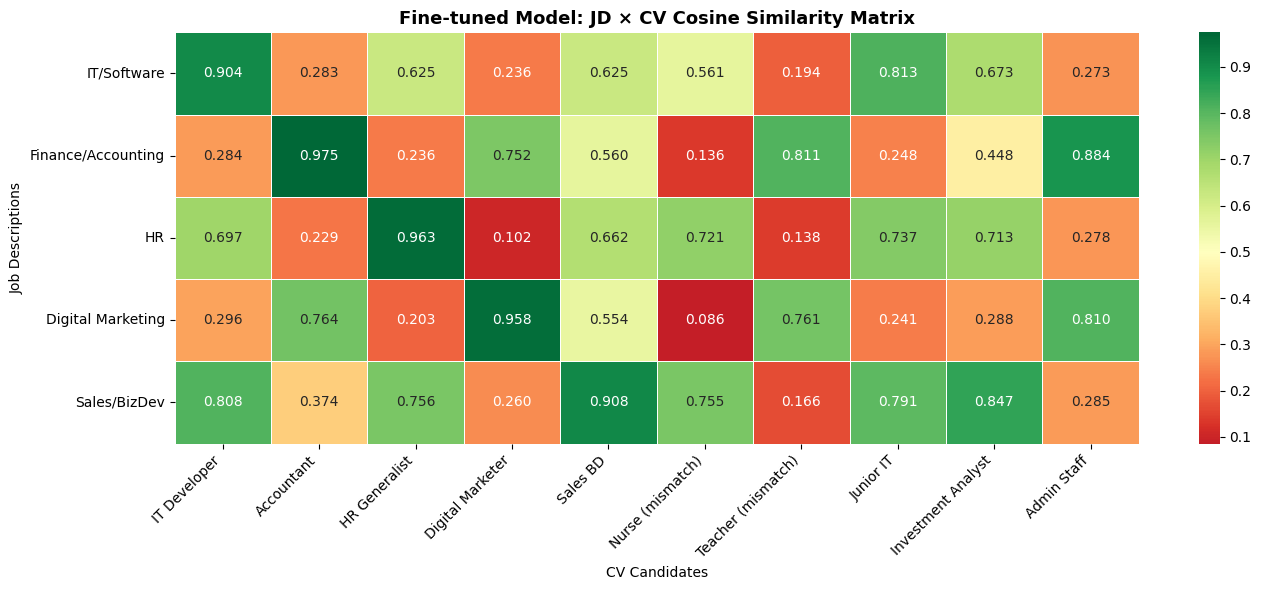

📊 Heatmap saved to: /content/drive/MyDrive/CVPRO/reports/qualitative_similarity_heatmap.png


In [31]:
# === Heatmap: JD vs CV Similarity Matrix ===
print("\n📊 Creating similarity heatmap...")

sim_matrix = np.zeros((len(sample_jds), len(sample_cvs)))
for i in range(len(sample_jds)):
    for j in range(len(sample_cvs)):
        sim_matrix[i][j] = util.cos_sim(jd_embeddings[i], cv_embeddings[j]).item()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    sim_matrix,
    xticklabels=sample_cv_labels,
    yticklabels=sample_jd_labels,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0.5,
    linewidths=0.5,
    ax=ax,
)
ax.set_title('Fine-tuned Model: JD × CV Cosine Similarity Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('CV Candidates')
ax.set_ylabel('Job Descriptions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

heatmap_path = os.path.join(PLOTS_DIR, 'qualitative_similarity_heatmap.png')
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Heatmap saved to: {heatmap_path}")

---
## Section 7: 🐛 Error Analysis
Analisis mendalam per-domain untuk mengidentifikasi kelemahan model.
- Domain mana yang performanya paling rendah?
- Contoh false positives (similarity tinggi tapi domain salah)
- Contoh false negatives (similarity rendah tapi seharusnya cocok)

In [32]:
# === Per-Domain Triplet Accuracy ===
# Jika test_df memiliki kolom domain, kita bisa breakdown per domain
# Jika tidak, kita buat domain detection sederhana berdasarkan keyword

# Domain detection berdasarkan keyword matching di anchor text
# Ini fallback jika kolom 'domain' tidak ada di dataset
DOMAIN_KEYWORDS = {
    'IT': ['software', 'developer', 'engineer', 'programming', 'python', 'java',
           'cloud', 'devops', 'fullstack', 'backend', 'frontend', 'data engineer',
           'machine learning', 'IT', 'teknologi informasi', 'programmer'],
    'Finance': ['finance', 'accounting', 'akuntansi', 'keuangan', 'audit', 'tax',
                'pajak', 'bookkeeping', 'financial', 'bank', 'investment'],
    'HR': ['human resource', 'HR', 'recruitment', 'talent', 'people', 'SDM',
           'sumber daya manusia', 'payroll', 'personnel', 'employee relation'],
    'Marketing': ['marketing', 'digital marketing', 'SEO', 'SEM', 'content',
                  'social media', 'advertising', 'brand', 'pemasaran', 'creative'],
    'Sales': ['sales', 'business development', 'account manager', 'revenue',
              'client relationship', 'B2B', 'penjualan', 'target', 'deal'],
    'Healthcare': ['nurse', 'doctor', 'medical', 'healthcare', 'hospital',
                   'kesehatan', 'perawat', 'farmasi', 'clinical'],
    'General': ['admin', 'general', 'operational', 'customer service', 'support',
                'assistant', 'staff', 'koordinator'],
}

def detect_domain(text):
    """Deteksi domain dari teks berdasarkan keyword matching"""
    text_lower = text.lower()
    domain_scores = {}
    for domain, keywords in DOMAIN_KEYWORDS.items():
        score = sum(1 for kw in keywords if kw.lower() in text_lower)
        domain_scores[domain] = score
    best_domain = max(domain_scores, key=domain_scores.get)
    if domain_scores[best_domain] == 0:
        return 'Other'
    return best_domain

# Assign domains to test set
if 'domain' not in test_df.columns:
    print("ℹ️  Kolom 'domain' tidak ditemukan di test set. Menggunakan keyword detection...")
    test_df['domain_detected'] = test_df['anchor'].apply(detect_domain)
    domain_col = 'domain_detected'
else:
    domain_col = 'domain'

print(f"\n📊 DOMAIN DISTRIBUTION IN TEST SET:")
domain_counts = test_df[domain_col].value_counts()
print(domain_counts.to_string())


📊 DOMAIN DISTRIBUTION IN TEST SET:
domain
Marketing      157
Sales          156
HR             155
IT             131
Education      131
Finance        130
Healthcare     130
Legal          129
Operational    129


In [35]:
# === Per-Domain Triplet Accuracy Breakdown ===
print("\n" + "=" * 65)
print("📊 PER-DOMAIN TRIPLET ACCURACY (Fine-tuned Model)")
print("=" * 65)

domain_results = {}

for domain in sorted(test_df[domain_col].unique()):
    domain_df = test_df[test_df[domain_col] == domain]

    if len(domain_df) < 5:
        print(f"   ⚠️  {domain}: skipped (only {len(domain_df)} samples)")
        continue

    domain_evaluator = evaluation.TripletEvaluator(
        anchors=domain_df['anchor'].tolist(),
        positives=domain_df['positive'].tolist(),
        negatives=domain_df['negative'].tolist(),
        name=f'domain_{domain}',
        batch_size=64,
    )
    domain_score = domain_evaluator(finetuned_model)

    # Fix: extract float from dict
    if isinstance(domain_score, dict):
        domain_score = list(domain_score.values())[0]

    domain_results[domain] = {
        'accuracy': domain_score,
        'count': len(domain_df),
    }

    emoji = "✅" if domain_score >= 0.85 else ("⚠️" if domain_score >= 0.70 else "❌")
    print(f"   {emoji} {domain:<15} : {domain_score:.4f} ({domain_score*100:.2f}%)  "
          f"[n={len(domain_df)}]")

print("=" * 65)

# Find worst performing domains
if domain_results:
    worst_domain = min(domain_results, key=lambda d: domain_results[d]['accuracy'])
    best_domain = max(domain_results, key=lambda d: domain_results[d]['accuracy'])
    print(f"\n   🏆 Best domain  : {best_domain} "
          f"({domain_results[best_domain]['accuracy']*100:.2f}%)")
    print(f"   ⚠️  Worst domain : {worst_domain} "
          f"({domain_results[worst_domain]['accuracy']*100:.2f}%)")


📊 PER-DOMAIN TRIPLET ACCURACY (Fine-tuned Model)
   ⚠️ Education       : 0.8397 (83.97%)  [n=131]
   ✅ Finance         : 0.8615 (86.15%)  [n=130]
   ✅ HR              : 0.8903 (89.03%)  [n=155]
   ✅ Healthcare      : 0.8615 (86.15%)  [n=130]
   ⚠️ IT              : 0.7786 (77.86%)  [n=131]
   ⚠️ Legal           : 0.8062 (80.62%)  [n=129]
   ✅ Marketing       : 0.9045 (90.45%)  [n=157]
   ⚠️ Operational     : 0.7054 (70.54%)  [n=129]
   ⚠️ Sales           : 0.8333 (83.33%)  [n=156]

   🏆 Best domain  : Marketing (90.45%)
   ⚠️  Worst domain : Operational (70.54%)


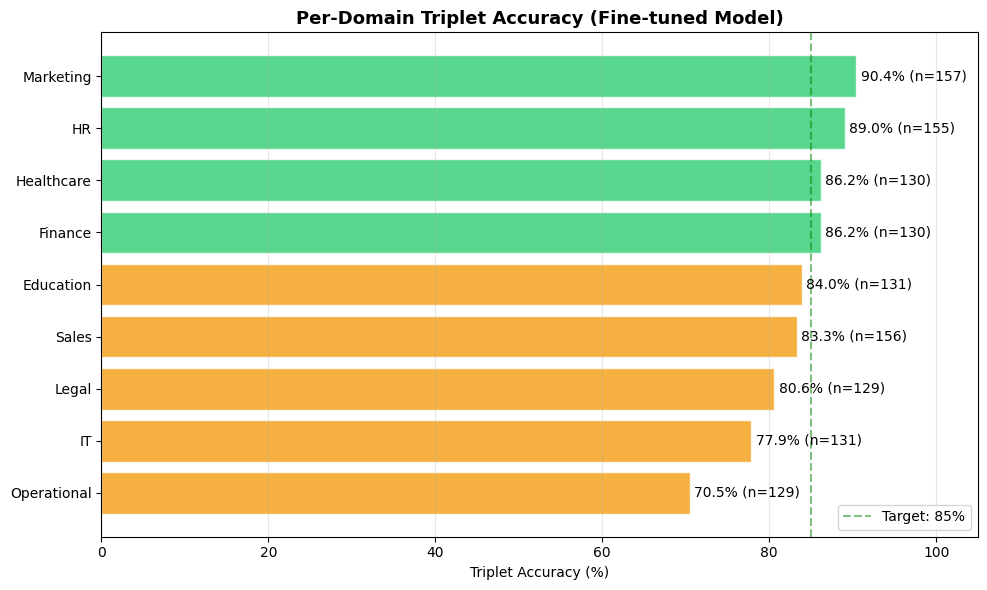

📊 Plot saved to: /content/drive/MyDrive/CVPRO/reports/per_domain_accuracy.png


In [36]:
# === Plot Per-Domain Accuracy ===
if domain_results:
    domains_sorted = sorted(domain_results.keys(),
                            key=lambda d: domain_results[d]['accuracy'])
    accuracies = [domain_results[d]['accuracy'] * 100 for d in domains_sorted]
    counts = [domain_results[d]['count'] for d in domains_sorted]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Bar chart for accuracy
    colors = ['#e74c3c' if a < 70 else '#f39c12' if a < 85 else '#2ecc71' for a in accuracies]
    bars = ax1.barh(domains_sorted, accuracies, color=colors, alpha=0.8, edgecolor='white')

    # Add count labels
    for i, (bar, count, acc) in enumerate(zip(bars, counts, accuracies)):
        ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{acc:.1f}% (n={count})', va='center', fontsize=10)

    ax1.set_xlabel('Triplet Accuracy (%)')
    ax1.set_title('Per-Domain Triplet Accuracy (Fine-tuned Model)', fontsize=13, fontweight='bold')
    ax1.axvline(x=85, color='green', linestyle='--', alpha=0.5, label='Target: 85%')
    ax1.set_xlim(0, 105)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    domain_plot_path = os.path.join(PLOTS_DIR, 'per_domain_accuracy.png')
    plt.savefig(domain_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"📊 Plot saved to: {domain_plot_path}")

In [37]:
# === Error Analysis: False Positives & False Negatives ===
# False Positive = cosine(anchor, negative) > cosine(anchor, positive) → model salah pilih
# Kita identifikasi contoh-contoh di mana model "gagal"

print("\n" + "=" * 70)
print("🐛 ERROR ANALYSIS: False Positive & False Negative Examples")
print("=" * 70)

# Compute similarities for entire test set
print("\nEncoding test set for error analysis...")
test_anchors = finetuned_model.encode(test_df['anchor'].tolist(), batch_size=64,
                                       show_progress_bar=True)
test_positives = finetuned_model.encode(test_df['positive'].tolist(), batch_size=64,
                                         show_progress_bar=True)
test_negatives = finetuned_model.encode(test_df['negative'].tolist(), batch_size=64,
                                         show_progress_bar=True)

# Calculate per-sample scores
test_pos_scores = []
test_neg_scores = []

for i in range(len(test_df)):
    pos_sim = util.cos_sim(test_anchors[i], test_positives[i]).item()
    neg_sim = util.cos_sim(test_anchors[i], test_negatives[i]).item()
    test_pos_scores.append(pos_sim)
    test_neg_scores.append(neg_sim)

test_df_analysis = test_df.copy()
test_df_analysis['pos_sim'] = test_pos_scores
test_df_analysis['neg_sim'] = test_neg_scores
test_df_analysis['margin'] = test_df_analysis['pos_sim'] - test_df_analysis['neg_sim']
test_df_analysis['correct'] = test_df_analysis['margin'] > 0

# Overall stats
n_correct = test_df_analysis['correct'].sum()
n_total = len(test_df_analysis)
n_errors = n_total - n_correct

print(f"\n📊 Overall: {n_correct}/{n_total} correct ({n_correct/n_total*100:.2f}%)")
print(f"   Errors: {n_errors} triplets where model preferred the wrong CV")


🐛 ERROR ANALYSIS: False Positive & False Negative Examples

Encoding test set for error analysis...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]


📊 Overall: 1041/1248 correct (83.41%)
   Errors: 207 triplets where model preferred the wrong CV


In [38]:
# === Show Error Examples (False Positives) ===
# Kasus di mana model memberikan score lebih tinggi ke negative daripada positive
errors = test_df_analysis[~test_df_analysis['correct']].sort_values('margin')

if len(errors) > 0:
    print(f"\n🔴 TOP FALSE POSITIVE EXAMPLES (model chose negative over positive):")
    print(f"   Showing worst {min(5, len(errors))} errors:\n")

    for idx, (_, row) in enumerate(errors.head(5).iterrows()):
        print(f"   --- Error #{idx+1} (margin={row['margin']:.4f}) ---")
        print(f"   📌 Anchor (JD): {str(row['anchor'])[:150]}...")
        print(f"   ✅ Positive (sim={row['pos_sim']:.4f}): {str(row['positive'])[:120]}...")
        print(f"   ❌ Negative (sim={row['neg_sim']:.4f}): {str(row['negative'])[:120]}...")
        if domain_col in row:
            print(f"   🏷️  Domain: {row[domain_col]}")
        print()
else:
    print("\n✅ No errors found! Model correctly ranked all triplets.")


🔴 TOP FALSE POSITIVE EXAMPLES (model chose negative over positive):
   Showing worst 5 errors:

   --- Error #1 (margin=-0.2195) ---
   📌 Anchor (JD): Description Job Title: Sales Manager Reports to: Studio Owner COMPANY OVERVIEW: YogaSix believes everyone deserves the mind-body experience of yoga. Y...
   ✅ Positive (sim=0.6299): ASSISTANT COMPANY SECRETARY Summary Reliable Legal Secretary successful at maintaining complex docket systems, tracking ...
   ❌ Negative (sim=0.8493): skills Team building expertise Proven sales track record Relationship selling Strong deal closer Skilled multi-tasker An...
   🏷️  Domain: Marketing

   --- Error #2 (margin=-0.1988) ---
   📌 Anchor (JD): Wichita Supply Chain Management Tutor Jobs The Varsity Tutors platform has thousands of students looking for online Supply Chain Management tutors nat...
   ✅ Positive (sim=0.5942): education, administering injections (IM, ID, Sub-Q, Z-track technique,) performing phlebotomy (Butterfly, Vaccutainer, N...
   

In [39]:
# === Show Hardest Correct Examples (narrow margins) ===
# Kasus yang benar tapi dengan margin sangat tipis — potensi error di masa depan
correct_samples = test_df_analysis[test_df_analysis['correct']].sort_values('margin')

print(f"\n🟡 TOP HARDEST CORRECT EXAMPLES (narrowest positive margins):")
print(f"   Showing {min(5, len(correct_samples))} examples with thinnest margin:\n")

for idx, (_, row) in enumerate(correct_samples.head(5).iterrows()):
    print(f"   --- Hard case #{idx+1} (margin={row['margin']:.4f}) ---")
    print(f"   📌 Anchor: {str(row['anchor'])[:120]}...")
    print(f"   ✅ Positive (sim={row['pos_sim']:.4f}): {str(row['positive'])[:100]}...")
    print(f"   ❌ Negative (sim={row['neg_sim']:.4f}): {str(row['negative'])[:100]}...")
    print()


🟡 TOP HARDEST CORRECT EXAMPLES (narrowest positive margins):
   Showing 5 examples with thinnest margin:

   --- Hard case #1 (margin=0.0006) ---
   📌 Anchor: Want to learn more about this role and Jobot? Click our Jobot logo and follow our LinkedIn page! Job details Urgently Hi...
   ✅ Positive (sim=0.6576): experience applying exceptional customer service and resolving complex billing issues. Highlights Se...
   ❌ Negative (sim=0.6570): Education Early childhood 2006 Touro College － City , State A.S , Liberal arts 2000 Kingsborough Com...

   --- Hard case #2 (margin=0.0006) ---
   📌 Anchor: If you live in the Medford, OR area, have your P & C insurance license and have some Commercial Lines agency experience,...
   ✅ Positive (sim=0.6841): skills &dedicated and Maintain customer centricity in all initiatives &Our guests routinely rave abo...
   ❌ Negative (sim=0.6834): skills in cross-functional, team-based environment, multi cultural, with the ability to effectively ...

   --- Ha

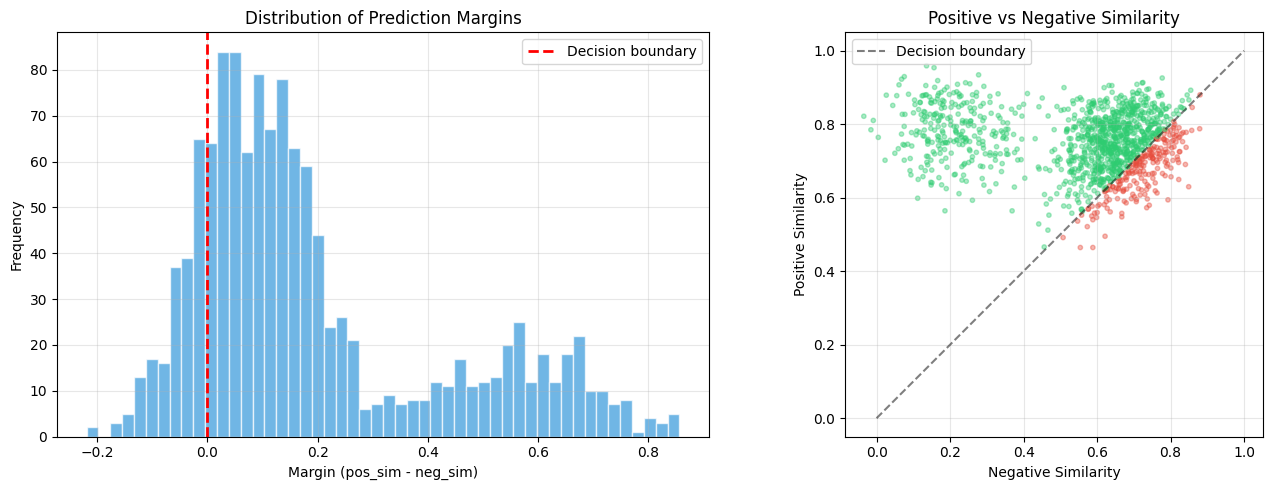

📊 Plot saved to: /content/drive/MyDrive/CVPRO/reports/error_analysis.png


In [40]:
# === Margin Distribution Plot ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Margin distribution
axes[0].hist(test_df_analysis['margin'], bins=50, color='#3498db', alpha=0.7, edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Decision boundary')
axes[0].set_xlabel('Margin (pos_sim - neg_sim)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Prediction Margins')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter: positive sim vs negative sim
colors = ['#2ecc71' if c else '#e74c3c' for c in test_df_analysis['correct']]
axes[1].scatter(test_df_analysis['neg_sim'], test_df_analysis['pos_sim'],
                c=colors, alpha=0.4, s=10)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Decision boundary')
axes[1].set_xlabel('Negative Similarity')
axes[1].set_ylabel('Positive Similarity')
axes[1].set_title('Positive vs Negative Similarity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal')

plt.tight_layout()
error_plot_path = os.path.join(PLOTS_DIR, 'error_analysis.png')
plt.savefig(error_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Plot saved to: {error_plot_path}")

---
## Section 8: 💾 Export & Deployment Instructions
Menyimpan model final, metrics, dan instruksi deployment.

In [42]:
# === Save All Metrics to JSON ===
import json
from datetime import datetime

metrics_summary = {
    'project': 'CV Matcher Pro — Dicoding Capstone',
    'timestamp': datetime.now().isoformat(),
    'base_model': BASE_MODEL,
    'fine_tuned_model_path': OUTPUT_DIR,

    # Training config
    'training_config': {
        'epochs': int(training_args.num_train_epochs),
        'batch_size': int(training_args.per_device_train_batch_size),
        'learning_rate': float(training_args.learning_rate),
        'warmup_ratio': 0.1,
        'lr_scheduler': str(training_args.lr_scheduler_type),
        'loss_function': 'MultipleNegativesRankingLoss',
        'fp16': bool(training_args.fp16),
        'early_stopping_patience': 2,
    },

    # Dataset stats
    'dataset': {
        'train_samples': len(train_df),
        'val_samples': len(val_df),
        'test_samples': len(test_df),
        'total_samples': len(train_df) + len(val_df) + len(test_df),
    },

    # Evaluation results
    'evaluation': {
        'baseline_test_accuracy': float(baseline_test_score),
        'baseline_val_accuracy': float(baseline_val_score),
        'finetuned_test_accuracy': float(finetuned_test_score),
        'finetuned_val_accuracy': float(finetuned_val_score),
        'test_improvement_pct': float((finetuned_test_score - baseline_test_score) * 100),
        'val_improvement_pct': float((finetuned_val_score - baseline_val_score) * 100),
    },

    # Per-domain results
    'per_domain_accuracy': {
        d: {
            'accuracy': float(v['accuracy']),
            'sample_count': int(v['count']),
        }
        for d, v in domain_results.items()
    },

    # Error stats
    'error_analysis': {
        'total_test_samples': int(n_total),
        'correct_predictions': int(n_correct),
        'incorrect_predictions': int(n_errors),
        'error_rate_pct': float(n_errors / n_total * 100),
        'mean_positive_sim': float(np.mean(test_pos_scores)),
        'mean_negative_sim': float(np.mean(test_neg_scores)),
        'mean_margin': float(np.mean(test_df_analysis['margin'])),
    },

    # Training time
    'training_time_minutes': round(training_minutes, 1),
}

metrics_json_path = os.path.join(MODEL_DIR, 'training_metrics.json')
with open(metrics_json_path, 'w') as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)
print(f"📄 Metrics saved to: {metrics_json_path}")

# Also save to reports dir
metrics_report_path = os.path.join(PLOTS_DIR, 'training_metrics.json')
with open(metrics_report_path, 'w') as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)
print(f"📄 Metrics also saved to: {metrics_report_path}")

📄 Metrics saved to: /content/drive/MyDrive/CVPRO/models/bi-encoder-cv-matcher/training_metrics.json
📄 Metrics also saved to: /content/drive/MyDrive/CVPRO/reports/training_metrics.json


In [43]:
# === Verify Model Can Be Loaded ===
print("\n🔍 Verifying model can be loaded successfully...")
try:
    verification_model = SentenceTransformer(OUTPUT_DIR)

    # Quick test
    test_texts = [
        "Software Engineer with Python experience",
        "Akuntan berpengalaman di bidang perpajakan",
    ]
    test_embs = verification_model.encode(test_texts)

    sim = util.cos_sim(test_embs[0], test_embs[1]).item()
    print(f"   ✅ Model loaded and working!")
    print(f"   Test similarity (IT vs Finance): {sim:.4f} (expected: low)")
    print(f"   Embedding dimension: {test_embs.shape[1]}")

    del verification_model
except Exception as e:
    print(f"   ❌ Error loading model: {e}")


🔍 Verifying model can be loaded successfully...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

   ✅ Model loaded and working!
   Test similarity (IT vs Finance): 0.4711 (expected: low)
   Embedding dimension: 384


In [44]:
# === Deployment Instructions ===
print("\n" + "=" * 70)
print("📋 DEPLOYMENT INSTRUCTIONS / INSTRUKSI DEPLOYMENT")
print("=" * 70)
print("""
Model fine-tuned berhasil disimpan di Google Drive:
📂 {model_dir}

=== Cara menggunakan model di backend ===

1. Download dari Google Drive:
   # Dari Google Colab:
   !cp -r '{model_dir}' /content/model_export/

   # Atau download manual dari Google Drive → folder CVPRO/models/

2. Copy ke project backend:
   cp -r CVPRO/models/bi-encoder-cv-matcher/ backend/models/

3. Load di Python:
   from sentence_transformers import SentenceTransformer

   model = SentenceTransformer('backend/models/bi-encoder-cv-matcher/')

   # Encode JD dan CV
   jd_embedding = model.encode("Job description text...")
   cv_embedding = model.encode("CV/resume text...")

   # Hitung similarity
   from sentence_transformers.util import cos_sim
   score = cos_sim(jd_embedding, cv_embedding).item()
   print(f"Match score: {{score:.4f}}")

4. Untuk HuggingFace Hub (optional):
   model.push_to_hub("your-username/cv-matcher-bi-encoder")

=== File yang dihasilkan ===
- model.safetensors     : Model weights
- config.json           : Model configuration
- tokenizer.json        : Tokenizer
- training_metrics.json : Semua metrics dalam format JSON
- training_metrics.png  : Visualisasi training curves
""".format(model_dir=OUTPUT_DIR))


📋 DEPLOYMENT INSTRUCTIONS / INSTRUKSI DEPLOYMENT

Model fine-tuned berhasil disimpan di Google Drive:
📂 /content/drive/MyDrive/CVPRO/models/bi-encoder-cv-matcher

=== Cara menggunakan model di backend ===

1. Download dari Google Drive:
   # Dari Google Colab:
   !cp -r '/content/drive/MyDrive/CVPRO/models/bi-encoder-cv-matcher' /content/model_export/

   # Atau download manual dari Google Drive → folder CVPRO/models/

2. Copy ke project backend:
   cp -r CVPRO/models/bi-encoder-cv-matcher/ backend/models/

3. Load di Python:
   from sentence_transformers import SentenceTransformer

   model = SentenceTransformer('backend/models/bi-encoder-cv-matcher/')

   # Encode JD dan CV
   jd_embedding = model.encode("Job description text...")
   cv_embedding = model.encode("CV/resume text...")

   # Hitung similarity
   from sentence_transformers.util import cos_sim
   score = cos_sim(jd_embedding, cv_embedding).item()
   print(f"Match score: {score:.4f}")

4. Untuk HuggingFace Hub (optional):


In [45]:
# === Final Summary ===
print("\n" + "=" * 70)
print("🎯 FINAL TRAINING SUMMARY / RINGKASAN AKHIR")
print("=" * 70)
print(f"""
📊 Model Performance:
   ┌─────────────────────────────┬──────────────┬──────────────┬────────────┐
   │ Metric                      │ Baseline     │ Fine-tuned   │ Δ Change   │
   ├─────────────────────────────┼──────────────┼──────────────┼────────────┤
   │ Triplet Accuracy (Test)     │ {baseline_test_score:>11.4f}  │ {finetuned_test_score:>11.4f}  │ {(finetuned_test_score-baseline_test_score)*100:>+9.2f}%  │
   │ Triplet Accuracy (Val)      │ {baseline_val_score:>11.4f}  │ {finetuned_val_score:>11.4f}  │ {(finetuned_val_score-baseline_val_score)*100:>+9.2f}%  │
   └─────────────────────────────┴──────────────┴──────────────┴────────────┘

⏱️  Training Time  : {training_minutes:.1f} minutes
📦 Dataset Size    : {len(train_df)+len(val_df)+len(test_df):,} total triplets
🤖 Model Size     : ~{sum(p.numel() for p in finetuned_model.parameters()) * 4 / 1e6:.0f} MB (FP32)
📁 Model Path     : {OUTPUT_DIR}

📊 Per-Domain Performance:""")

for domain in sorted(domain_results.keys()):
    acc = domain_results[domain]['accuracy']
    n = domain_results[domain]['count']
    bar = "█" * int(acc * 20) + "░" * (20 - int(acc * 20))
    print(f"   {domain:<15} [{bar}] {acc*100:5.1f}% (n={n})")

print(f"""
📈 Error Analysis:
   Total errors  : {n_errors}/{n_total} ({n_errors/n_total*100:.2f}%)
   Mean margin   : {np.mean(test_df_analysis['margin']):.4f}
   Mean pos sim  : {np.mean(test_pos_scores):.4f}
   Mean neg sim  : {np.mean(test_neg_scores):.4f}

📁 Output Files:
   📂 {MODEL_DIR}/
   📄 {os.path.join(MODEL_DIR, 'training_metrics.json')}
   📊 {os.path.join(PLOTS_DIR, 'training_metrics.png')}
   📊 {os.path.join(PLOTS_DIR, 'similarity_distribution_comparison.png')}
   📊 {os.path.join(PLOTS_DIR, 'per_domain_accuracy.png')}
   📊 {os.path.join(PLOTS_DIR, 'error_analysis.png')}
   📊 {os.path.join(PLOTS_DIR, 'qualitative_similarity_heatmap.png')}
""")

print("=" * 70)
print("✅ Notebook 04 selesai! Model siap untuk deployment.")
print("   Lanjut ke langkah integrasi backend (Notebook 05 atau manual).")
print("=" * 70)


🎯 FINAL TRAINING SUMMARY / RINGKASAN AKHIR

📊 Model Performance:
   ┌─────────────────────────────┬──────────────┬──────────────┬────────────┐
   │ Metric                      │ Baseline     │ Fine-tuned   │ Δ Change   │
   ├─────────────────────────────┼──────────────┼──────────────┼────────────┤
   │ Triplet Accuracy (Test)     │      0.6546  │      0.8341  │    +17.95%  │
   │ Triplet Accuracy (Val)      │      0.6386  │      0.8413  │    +20.27%  │
   └─────────────────────────────┴──────────────┴──────────────┴────────────┘

⏱️  Training Time  : 9.8 minutes
📦 Dataset Size    : 12,480 total triplets
🤖 Model Size     : ~471 MB (FP32)
📁 Model Path     : /content/drive/MyDrive/CVPRO/models/bi-encoder-cv-matcher

📊 Per-Domain Performance:
   Education       [████████████████░░░░]  84.0% (n=131)
   Finance         [█████████████████░░░]  86.2% (n=130)
   HR              [█████████████████░░░]  89.0% (n=155)
   Healthcare      [█████████████████░░░]  86.2% (n=130)
   IT              [██